In [90]:
# Always runn the below commented in the terminal only to have pandas connected to my project venv
# pip install pandas

import pandas as pd
print(pd.__version__)


3.0.0


# ONE LINER TABLE IMPORT


In [91]:
# I can use this one block of code to load my data from supase client, just uncomment 
## OR I can use the following loading steps after this block of code

#import sys
#import os

## Allow notebook to access project modules
# sys.path.append(os.path.abspath(".."))

# from datasrc.supabase_loader import load_market_data


# df = load_market_data(limit=1000)

# df.head()

In [92]:
import sys
import os

# Get project root (go one level up from notebooks folder)
sys.path.append(os.path.abspath(".."))

# Now this will work
from datasrc.supabase_loader import load_financial_dataset

In [93]:


df_financial = load_financial_dataset()




In [94]:
df_financial.head(180)

,id,symbol,statement_type,report_date,period,report_id_x,revenue,net_income,gross_profit,eps,report_id_y,total_assets,total_liabilities,total_equity,total_debt,report_id,operating_cash_flow,free_cash_flow,capital_expenditure
0,1,AAPL,income-statement,2025-09-27,FY,1.0,4.161610e+11,1.120100e+11,1.952010e+11,7.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,AAPL,income-statement,2024-09-28,FY,2.0,3.910350e+11,9.373600e+10,1.806830e+11,6.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,AAPL,income-statement,2023-09-30,FY,3.0,3.832850e+11,9.699500e+10,1.691480e+11,6.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,AAPL,income-statement,2022-09-24,FY,4.0,3.943280e+11,9.980300e+10,1.707820e+11,6.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,AAPL,income-statement,2021-09-25,FY,5.0,3.658170e+11,9.468000e+10,1.528360e+11,5.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,AAPL,balance-sheet-statement,2025-09-27,FY,NaN,NaN,NaN,NaN,NaN,6.0,3.592410e+11,2.855080e+11,7.373300e+10,1.123770e+11,NaN,NaN,NaN,NaN
6,7,AAPL,balance-sheet-statement,2024-09-28,FY,NaN,NaN,NaN,NaN,NaN,7.0,3.649800e+11,3.080300e+11,5.695000e+10,1.190590e+11,NaN,NaN,NaN,NaN
7,8,AAPL,balance-sheet-statement,2023-09-30,FY,NaN,NaN,NaN,NaN,NaN,8.0,3.525830e+11,2.904370e+11,6.214600e+10,1.239300e+11,NaN,NaN,NaN,NaN
8,9,AAPL,balance-sheet-statement,2022-09-24,FY,NaN,NaN,NaN,NaN,NaN,9.0,3.527550e+11,3.020830e+11,5.067200e+10,1.324800e+11,NaN,NaN,NaN,NaN
9,10,AAPL,balance-sheet-statement,2021-09-25,FY,NaN,NaN,NaN,NaN,NaN,10.0,3.510020e+11,2.879120e+11,6.309000e+10,1.365220e+11,NaN,NaN,NaN,NaN


In [95]:
# Create a copy of the original dataframe to work with

df = df_financial.copy()

In [96]:

df = df.sort_values(["symbol", "report_date"])      # Sort by symbol and report date to ensure correct order for forward filling

In [97]:
# Keep only the first entry for each symbol and report date combination, which should be the most complete one after sorting
df_clean = df.groupby(["symbol", "report_date"]).first().reset_index()

# Drop statement_type, This column is not needed for analysis and has many missing values
df_clean = df_clean.drop(columns=["statement_type"], errors="ignore")

In [98]:
df_clean.head(180)

,symbol,report_date,id,period,report_id_x,revenue,net_income,gross_profit,eps,report_id_y,total_assets,total_liabilities,total_equity,total_debt,report_id,operating_cash_flow,free_cash_flow,capital_expenditure
0,AAPL,2021-09-25,5,FY,5.0,3.658170e+11,9.468000e+10,1.528360e+11,5.67,10.0,3.510020e+11,2.879120e+11,6.309000e+10,1.365220e+11,15.0,1.040380e+11,9.295300e+10,-1.108500e+10
1,AAPL,2022-09-24,4,FY,4.0,3.943280e+11,9.980300e+10,1.707820e+11,6.15,9.0,3.527550e+11,3.020830e+11,5.067200e+10,1.324800e+11,14.0,1.221510e+11,1.114430e+11,-1.070800e+10
2,AAPL,2023-09-30,3,FY,3.0,3.832850e+11,9.699500e+10,1.691480e+11,6.16,8.0,3.525830e+11,2.904370e+11,6.214600e+10,1.239300e+11,13.0,1.105430e+11,9.958400e+10,-1.095900e+10
3,AAPL,2024-09-28,2,FY,2.0,3.910350e+11,9.373600e+10,1.806830e+11,6.11,7.0,3.649800e+11,3.080300e+11,5.695000e+10,1.190590e+11,12.0,1.182540e+11,1.088070e+11,-9.447000e+09
4,AAPL,2025-09-27,1,FY,1.0,4.161610e+11,1.120100e+11,1.952010e+11,7.49,6.0,3.592410e+11,2.855080e+11,7.373300e+10,1.123770e+11,11.0,1.114820e+11,9.876700e+10,-1.271500e+10
5,ADBE,2021-12-03,20,FY,20.0,1.578500e+10,4.822000e+09,1.392000e+10,10.10,25.0,2.724100e+10,1.244400e+10,1.479700e+10,4.673000e+09,30.0,7.223000e+09,6.893000e+09,-3.300000e+08
6,ADBE,2022-12-02,19,FY,19.0,1.760600e+10,4.756000e+09,1.544100e+10,10.13,24.0,2.716500e+10,1.311400e+10,1.405100e+10,4.633000e+09,29.0,7.838000e+09,7.396000e+09,-4.420000e+08
7,ADBE,2023-12-01,18,FY,18.0,1.940900e+10,5.428000e+09,1.705500e+10,11.88,23.0,2.977900e+10,1.326100e+10,1.651800e+10,4.080000e+09,28.0,7.302000e+09,6.942000e+09,-3.600000e+08
8,ADBE,2024-11-29,17,FY,17.0,2.150500e+10,5.560000e+09,1.914700e+10,12.44,22.0,3.023000e+10,1.612500e+10,1.410500e+10,6.056000e+09,27.0,8.056000e+09,7.824000e+09,-2.320000e+08
9,ADBE,2025-11-28,16,FY,16.0,2.376900e+10,7.130000e+09,2.106100e+10,16.73,21.0,2.949600e+10,1.787300e+10,1.162300e+10,6.648000e+09,26.0,1.003100e+10,9.852000e+09,-1.790000e+08


In [99]:
df_clean.tail(180)

,symbol,report_date,id,period,report_id_x,revenue,net_income,gross_profit,eps,report_id_y,total_assets,total_liabilities,total_equity,total_debt,report_id,operating_cash_flow,free_cash_flow,capital_expenditure
0,AAPL,2021-09-25,5,FY,5.0,3.658170e+11,9.468000e+10,1.528360e+11,5.67,10.0,3.510020e+11,2.879120e+11,6.309000e+10,1.365220e+11,15.0,1.040380e+11,9.295300e+10,-1.108500e+10
1,AAPL,2022-09-24,4,FY,4.0,3.943280e+11,9.980300e+10,1.707820e+11,6.15,9.0,3.527550e+11,3.020830e+11,5.067200e+10,1.324800e+11,14.0,1.221510e+11,1.114430e+11,-1.070800e+10
2,AAPL,2023-09-30,3,FY,3.0,3.832850e+11,9.699500e+10,1.691480e+11,6.16,8.0,3.525830e+11,2.904370e+11,6.214600e+10,1.239300e+11,13.0,1.105430e+11,9.958400e+10,-1.095900e+10
3,AAPL,2024-09-28,2,FY,2.0,3.910350e+11,9.373600e+10,1.806830e+11,6.11,7.0,3.649800e+11,3.080300e+11,5.695000e+10,1.190590e+11,12.0,1.182540e+11,1.088070e+11,-9.447000e+09
4,AAPL,2025-09-27,1,FY,1.0,4.161610e+11,1.120100e+11,1.952010e+11,7.49,6.0,3.592410e+11,2.855080e+11,7.373300e+10,1.123770e+11,11.0,1.114820e+11,9.876700e+10,-1.271500e+10
5,ADBE,2021-12-03,20,FY,20.0,1.578500e+10,4.822000e+09,1.392000e+10,10.10,25.0,2.724100e+10,1.244400e+10,1.479700e+10,4.673000e+09,30.0,7.223000e+09,6.893000e+09,-3.300000e+08
6,ADBE,2022-12-02,19,FY,19.0,1.760600e+10,4.756000e+09,1.544100e+10,10.13,24.0,2.716500e+10,1.311400e+10,1.405100e+10,4.633000e+09,29.0,7.838000e+09,7.396000e+09,-4.420000e+08
7,ADBE,2023-12-01,18,FY,18.0,1.940900e+10,5.428000e+09,1.705500e+10,11.88,23.0,2.977900e+10,1.326100e+10,1.651800e+10,4.080000e+09,28.0,7.302000e+09,6.942000e+09,-3.600000e+08
8,ADBE,2024-11-29,17,FY,17.0,2.150500e+10,5.560000e+09,1.914700e+10,12.44,22.0,3.023000e+10,1.612500e+10,1.410500e+10,6.056000e+09,27.0,8.056000e+09,7.824000e+09,-2.320000e+08
9,ADBE,2025-11-28,16,FY,16.0,2.376900e+10,7.130000e+09,2.106100e+10,16.73,21.0,2.949600e+10,1.787300e+10,1.162300e+10,6.648000e+09,26.0,1.003100e+10,9.852000e+09,-1.790000e+08


In [100]:
# Validate completeness:
df_clean.isnull().sum().sort_values(ascending=False)

symbol                 0
report_date            0
free_cash_flow         0
operating_cash_flow    0
report_id              0
total_debt             0
total_equity           0
total_liabilities      0
total_assets           0
report_id_y            0
eps                    0
gross_profit           0
net_income             0
revenue                0
report_id_x            0
period                 0
id                     0
capital_expenditure    0
dtype: int64

In [101]:
print("load_market_data" in globals())

True


# TABLE IMPORT

In [102]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


In [103]:
from datasrc.supabase_loader import load_market_data
# Load data from Supabase

## Fix Step 3 — Restart Kernel

## After modifying paths: RESTART KERNEL AT THE TOP MENU

## Now  ONLY Run your cells again from the top (Shift + Enter).




In [104]:
try:
    df = load_market_data()
except Exception as e:
    print(f"Connection error: {e}")
    print(f"Error type: {type(e).__name__}")

In [105]:
# print(load_market_data())

In [106]:
df = load_market_data()
print(df.shape)
df.head()

(51376, 9)


,id,scraped_at,sp_futures,dow_futures,nasdaq_futures,gold,crude_oil,russell_2000,vix
0,1681,2026-02-13T17:32:22.57587+00:00,6879.18,49682.86,22739.69,5037.0,NaN,2664.63,19.34
1,1682,2026-02-13T17:32:29.064421+00:00,6878.68,49681.41,22737.11,5037.3,NaN,2664.58,19.34
2,1683,2026-02-13T17:32:35.40857+00:00,6878.68,49682.78,22736.22,5037.3,NaN,2664.51,19.36
3,1684,2026-02-13T17:32:41.714729+00:00,6878.62,49680.89,22737.16,5037.3,NaN,2664.42,19.36
4,1685,2026-02-13T17:32:47.802792+00:00,6878.92,49681.59,22738.85,5037.2,NaN,2664.35,19.36


In [107]:
# Total number of rows
num_rows = len(df)
print(f"Total rows in the table: {num_rows}")

Total rows in the table: 51376


# Basic EDA Workflow

In [108]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 51376 entries, 0 to 51375
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              51376 non-null  int64  
 1   scraped_at      51376 non-null  str    
 2   sp_futures      40151 non-null  float64
 3   dow_futures     40151 non-null  float64
 4   nasdaq_futures  40151 non-null  float64
 5   gold            51376 non-null  float64
 6   crude_oil       27850 non-null  float64
 7   russell_2000    40151 non-null  float64
 8   vix             51370 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 3.5 MB


,id,sp_futures,dow_futures,nasdaq_futures,gold,crude_oil,russell_2000,vix
count,51376.000000,40151.000000,40151.000000,40151.000000,51376.000000,27850.000000,40151.000000,51370.000000
mean,27368.500000,6820.151565,48718.881848,22669.843172,4894.039382,98.802195,2633.131004,20.612198
std,14831.118052,73.912386,1020.432710,291.251463,147.028608,3.550842,40.173760,2.087587
min,1681.000000,6368.850000,45166.640000,20948.360000,4491.600000,91.270000,2426.360000,18.760000
25%,14524.750000,6816.890000,47916.570000,22546.670000,4787.400000,96.570000,2630.590000,19.230000
50%,27368.500000,6836.170000,49500.930000,22645.460000,4836.400000,96.570000,2646.700000,20.410000
75%,40212.250000,6836.170000,49500.930000,22902.900000,5046.300000,103.670000,2646.700000,21.010000
max,53056.000000,6915.790000,49741.950000,23183.740000,5130.000000,105.590000,2672.410000,31.050000


In [109]:
# Handle timestamps
# If you have a time column:

df["scraped_at"] = pd.to_datetime(df["scraped_at"])
df = df.sort_values("scraped_at")

# Reset index after sorting (clean index)
df = df.reset_index(drop=True)
df.head()

,id,scraped_at,sp_futures,dow_futures,nasdaq_futures,gold,crude_oil,russell_2000,vix
0,1681,2026-02-13 17:32:22.575870+00:00,6879.18,49682.86,22739.69,5037.0,NaN,2664.63,19.34
1,1682,2026-02-13 17:32:29.064421+00:00,6878.68,49681.41,22737.11,5037.3,NaN,2664.58,19.34
2,1683,2026-02-13 17:32:35.408570+00:00,6878.68,49682.78,22736.22,5037.3,NaN,2664.51,19.36
3,1684,2026-02-13 17:32:41.714729+00:00,6878.62,49680.89,22737.16,5037.3,NaN,2664.42,19.36
4,1685,2026-02-13 17:32:47.802792+00:00,6878.92,49681.59,22738.85,5037.2,NaN,2664.35,19.36


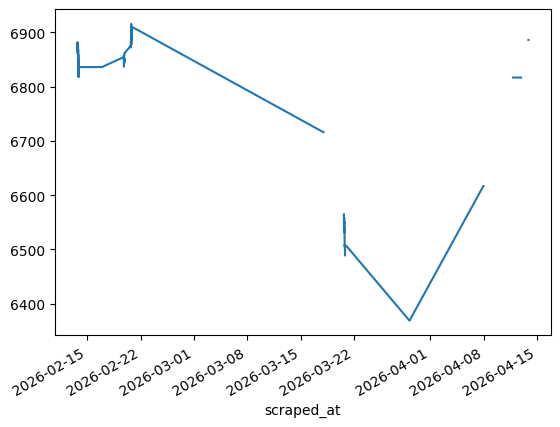

In [110]:
# Plot Time Series


# # Install matplotlib in the notebook environment if missing Uncomment below
# %pip install matplotlib

import matplotlib.pyplot as plt

df.set_index("scraped_at")["sp_futures"].plot()
plt.show()


In [111]:
## Missing values
print(df.isnull().sum())

id                    0
scraped_at            0
sp_futures        11225
dow_futures       11225
nasdaq_futures    11225
gold                  0
crude_oil         23526
russell_2000      11225
vix                   6
dtype: int64


In [112]:
# Example: check last row timestamp
df['scraped_at'].max()

Timestamp('2026-04-13 21:21:45.118589+0000', tz='UTC')

In [113]:
df.head()


,id,scraped_at,sp_futures,dow_futures,nasdaq_futures,gold,crude_oil,russell_2000,vix
0,1681,2026-02-13 17:32:22.575870+00:00,6879.18,49682.86,22739.69,5037.0,NaN,2664.63,19.34
1,1682,2026-02-13 17:32:29.064421+00:00,6878.68,49681.41,22737.11,5037.3,NaN,2664.58,19.34
2,1683,2026-02-13 17:32:35.408570+00:00,6878.68,49682.78,22736.22,5037.3,NaN,2664.51,19.36
3,1684,2026-02-13 17:32:41.714729+00:00,6878.62,49680.89,22737.16,5037.3,NaN,2664.42,19.36
4,1685,2026-02-13 17:32:47.802792+00:00,6878.92,49681.59,22738.85,5037.2,NaN,2664.35,19.36


# Rename a Column

In [114]:
# Rename column
# Syntax: rename(columns={"old_name": "new_name"})
df = df.rename(columns={"scraped_at": "created"})

df["created"] = pd.to_datetime(df["created"])

# Confirm rename worked
df.columns


Index(['id', 'created', 'sp_futures', 'dow_futures', 'nasdaq_futures', 'gold',
       'crude_oil', 'russell_2000', 'vix'],
      dtype='str')

# Remove a Column

In [115]:
# Drop column permanently
df = df.drop(columns=["crude_oil"])

# Confirm removal
df.columns


Index(['id', 'created', 'sp_futures', 'dow_futures', 'nasdaq_futures', 'gold',
       'russell_2000', 'vix'],
      dtype='str')

In [116]:
# Show column types and null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 51376 entries, 0 to 51375
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   id              51376 non-null  int64              
 1   created         51376 non-null  datetime64[us, UTC]
 2   sp_futures      40151 non-null  float64            
 3   dow_futures     40151 non-null  float64            
 4   nasdaq_futures  40151 non-null  float64            
 5   gold            51376 non-null  float64            
 6   russell_2000    40151 non-null  float64            
 7   vix             51370 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(6), int64(1)
memory usage: 3.1 MB


# Filter Last 1 Hour (Notebook Only)

In [117]:
from datetime import timedelta

# This creates a timezone-aware UTC timestamp
one_hour_ago = pd.Timestamp.now('UTC') - pd.Timedelta(hours=1)

# Now filtering works
df_last_1hr = df[df["created"] > one_hour_ago]

print(len(df_last_1hr))


# Print number of rows in last 1 hour
print("Rows in last 1 hour:", len(df_last_1hr))

df_last_1hr.head()


67
Rows in last 1 hour: 67


,id,created,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix
51309,52990,2026-04-13 21:15:05.699566+00:00,6886.24,48218.25,23183.74,4766.6,2670.49,19.12
51310,52991,2026-04-13 21:15:11.819801+00:00,6886.24,48218.25,23183.74,4766.6,2670.49,19.12
51311,52992,2026-04-13 21:15:18.206386+00:00,6886.24,48218.25,23183.74,4766.6,2670.49,19.12
51312,52993,2026-04-13 21:15:24.943902+00:00,6886.24,48218.25,23183.74,4766.6,2670.49,19.12
51313,52994,2026-04-13 21:15:30.913890+00:00,6886.24,48218.25,23183.74,4766.6,2670.49,NaN


# Plot Full Historical Time Series

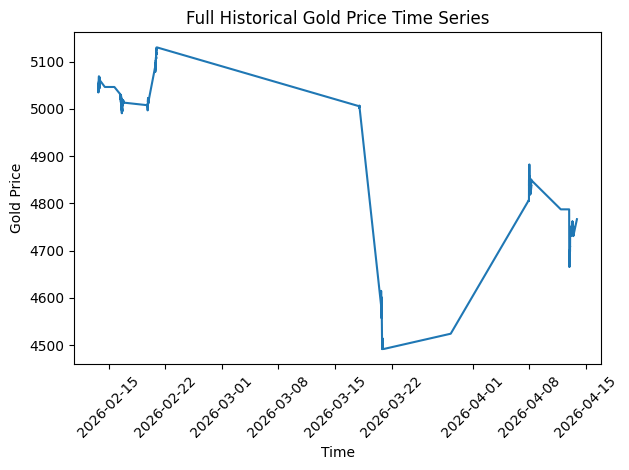

In [118]:
plt.figure()

# Plot full historical stock price
plt.plot(df["created"], df["gold"])

# Label axes
plt.xlabel("Time")
plt.ylabel("Gold Price")

# Title
plt.title("Full Historical Gold Price Time Series")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Plot Only Last 1 Hour

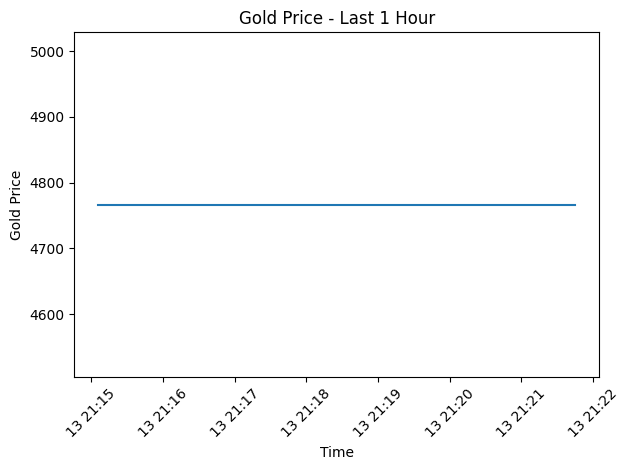

In [119]:
plt.figure()

# Plot only last 1 hour
plt.plot(df_last_1hr["created"], df_last_1hr["gold"])

plt.xlabel("Time")
plt.ylabel("Gold Price")
plt.title("Gold Price - Last 1 Hour")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Detect Time Gaps (Very Important)

In [120]:
# Calculate time difference between consecutive rows
# Calculate time difference
df["time_diff"] = df["created"].diff()

# Convert time difference to total seconds
df["time_diff_seconds"] = df["time_diff"].dt.total_seconds()

# Now sort by largest gaps
df.sort_values("time_diff_seconds", ascending=False).head()


,id,created,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,time_diff,time_diff_seconds
23046,24727,2026-03-17 23:12:57.238735+00:00,6716.09,46993.26,22479.53,5005.6,2503.29,23.51,24 days 23:28:55.242189,2.158135e+06
24977,26658,2026-04-07 23:02:11.118370+00:00,6616.85,46584.46,22017.85,4807.4,2544.95,25.78,9 days 16:04:57.382833,8.354974e+05
24626,26307,2026-03-29 06:22:10.950198+00:00,6368.85,45166.64,20948.36,4524.3,2449.70,31.05,8 days 06:04:33.373614,7.130734e+05
28870,30551,2026-04-11 21:01:12.511640+00:00,6816.89,47916.57,22902.90,4787.4,2630.59,19.23,3 days 15:15:17.723130,3.141177e+05
18179,19860,2026-02-19 19:22:31.376572+00:00,6854.69,49354.52,22660.04,5007.7,2650.65,20.40,2 days 21:02:13.576011,2.485336e+05


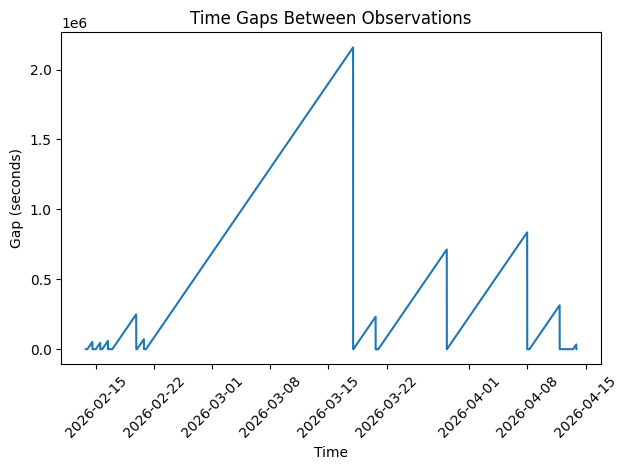

In [121]:
# You can also plot the time gaps:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["created"], df["time_diff_seconds"])
plt.xlabel("Time")
plt.ylabel("Gap (seconds)")
plt.title("Time Gaps Between Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Rolling Mean (Trend Smoothing)

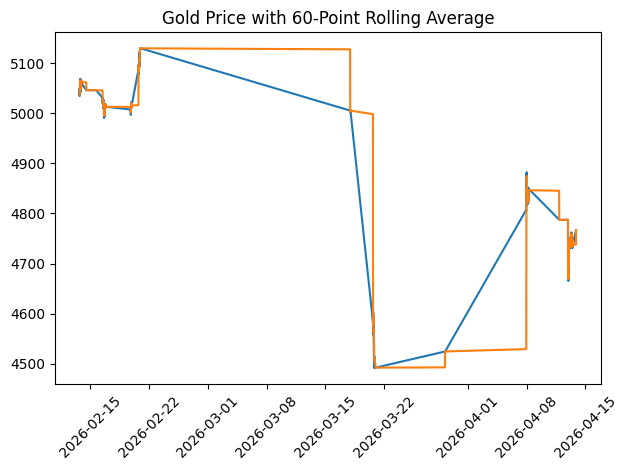

In [ ]:
# Calculate rolling average (moving average) # This smooths out short-term fluctuations and highlights longer-term trends in the data. # The window size (60 in this case) determines how many data points are averaged together. A larger window will produce a smoother curve but may lag more behind the actual data. # what does this mean in lay terms # A rolling average takes the average of a certain number of data points (the window) and moves that window across the data. For example, with a window of 60, it will take the average of the first 60 data points and assign that average to the 60th point. Then it moves one point forward, takes the average of points 2 to 61, and assigns that to the 61st point, and so on. This helps to smooth out short-term fluctuations (like noise) and makes it easier to see longer-term trends in the data. However, because it averages over a window, it can lag behind the actual data, especially if the window is large, meaning it may not reflect recent changes immediately.
df["rolling_mean_60"] = df["gold"].rolling(window=60).mean()

plt.figure()
plt.plot(df["created"], df["gold"])
plt.plot(df["created"], df["rolling_mean_60"])
plt.title("Gold Price with 60-Point Rolling Average")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Volatility (Standard Deviation)

In [ ]:
# Calculate rolling volatility # what does this mean in lay and yechnical terms # Rolling volatility is a measure of how much the price of an asset (like gold) fluctuates over a specific period (the window). In lay terms, it tells you how "bumpy" the price has been recently. A higher rolling volatility means the price has been changing a lot, while a lower rolling volatility means the price has been more stable. In technical terms, it's calculated as the standard deviation of the asset's returns over the rolling window. This can help traders and analysts understand the risk associated with the asset and identify periods of high or low market activity.
df["rolling_std_60"] = df["gold"].rolling(window=60).std()

df[["gold", "rolling_std_60"]].tail()


,gold,rolling_std_60
51371,4766.6,0.0
51372,4766.6,0.0
51373,4766.6,0.0
51374,4766.6,0.0
51375,4766.6,0.0


# Price Change per Second

In [ ]:
# Calculate price difference # This shows how much the price changed from one observation to the next. A positive value means the price went up, while a negative value means it went down. This can help you see the volatility and trends in the price over time.
df["price_change"] = df["gold"].diff()

df[["created", "price_change"]].tail()


,created,price_change
51371,2026-04-13 21:21:21.095724+00:00,0.0
51372,2026-04-13 21:21:27.024368+00:00,0.0
51373,2026-04-13 21:21:33.071245+00:00,0.0
51374,2026-04-13 21:21:39.091871+00:00,0.0
51375,2026-04-13 21:21:45.118589+00:00,0.0


# Data Structure Understanding

In [ ]:
# Check time differences # This can help you identify if there are any irregular time intervals in your data, which might indicate missing data or issues with the data collection process.
df["time_diff"] = df["created"].diff()

df["time_diff"].value_counts().head()


time_diff
0 days 00:00:06.104796    4
0 days 00:00:06.178651    4
0 days 00:00:06.095920    4
0 days 00:00:06.199798    4
0 days 00:00:06.112997    4
Name: count, dtype: int64

# Price Distribution

<Axes: >

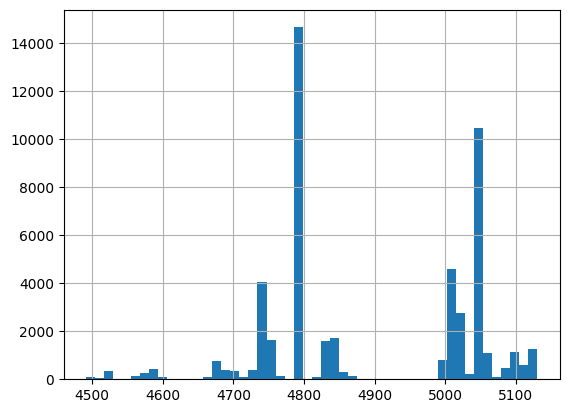

In [126]:
df["gold"].hist(bins=50)

# Breaking down

In [127]:
df['created'] = pd.to_datetime(df['created'])
df = df.sort_values('created')
df = df.set_index('created')

In [128]:
### You told Python Above Cell:

### “This is TIME data — treat it properly”

In [129]:
df.head()

,id,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,time_diff,time_diff_seconds,rolling_mean_60,rolling_std_60,price_change
created,,,,,,,,,,,,
2026-02-13 17:32:22.575870+00:00,1681,6879.18,49682.86,22739.69,5037.0,2664.63,19.34,NaT,NaN,NaN,NaN,NaN
2026-02-13 17:32:29.064421+00:00,1682,6878.68,49681.41,22737.11,5037.3,2664.58,19.34,0 days 00:00:06.488551,6.488551,NaN,NaN,0.3
2026-02-13 17:32:35.408570+00:00,1683,6878.68,49682.78,22736.22,5037.3,2664.51,19.36,0 days 00:00:06.344149,6.344149,NaN,NaN,0.0
2026-02-13 17:32:41.714729+00:00,1684,6878.62,49680.89,22737.16,5037.3,2664.42,19.36,0 days 00:00:06.306159,6.306159,NaN,NaN,0.0
2026-02-13 17:32:47.802792+00:00,1685,6878.92,49681.59,22738.85,5037.2,2664.35,19.36,0 days 00:00:06.088063,6.088063,NaN,NaN,-0.1


In [130]:
df.tail()

,id,sp_futures,dow_futures,nasdaq_futures,gold,russell_2000,vix,time_diff,time_diff_seconds,rolling_mean_60,rolling_std_60,price_change
created,,,,,,,,,,,,
2026-04-13 21:21:21.095724+00:00,53052,6886.24,48218.25,23183.74,4766.6,2670.49,19.12,0 days 00:00:05.953407,5.953407,4766.6,0.0,0.0
2026-04-13 21:21:27.024368+00:00,53053,6886.24,48218.25,23183.74,4766.6,2670.49,19.12,0 days 00:00:05.928644,5.928644,4766.6,0.0,0.0
2026-04-13 21:21:33.071245+00:00,53054,6886.24,48218.25,23183.74,4766.6,2670.49,19.12,0 days 00:00:06.046877,6.046877,4766.6,0.0,0.0
2026-04-13 21:21:39.091871+00:00,53055,6886.24,48218.25,23183.74,4766.6,2670.49,19.12,0 days 00:00:06.020626,6.020626,4766.6,0.0,0.0
2026-04-13 21:21:45.118589+00:00,53056,6886.24,48218.25,23183.74,4766.6,2670.49,19.12,0 days 00:00:06.026718,6.026718,4766.6,0.0,0.0


In [131]:
# Import psutil library for system and process utilities
# psutil provides an interface to retrieve information on running processes and system utilization
# (CPU, memory, disks, network) in a portable way
import psutil

# Get virtual memory details as a named tuple
# This returns memory statistics including total, available, used, free, etc.
# Useful for monitoring system resources programmatically
mem = psutil.virtual_memory()

# Print total memory in GB with 1 decimal place
# mem.total gives total physical memory in bytes
# Divide by (1024**3) to convert bytes to gigabytes
# Format as float with 1 decimal for readability
print(f"Total: {mem.total / (1024**3):.1f}GB")

# Print used memory in GB
# mem.used gives memory currently in use
# Same conversion and formatting as above
print(f"Used: {mem.used / (1024**3):.1f}GB") 

# Print available memory in GB
# mem.available gives memory available for new processes
# Note: available != free (includes memory that can be freed)
print(f"Free: {mem.available / (1024**3):.1f}GB")

Total: 16.0GB
Used: 4.9GB
Free: 3.0GB
